In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sys.path.append(str(Path('../utils').resolve()))

from funciones_eda import cardinalidad, plot_categorical_relationship_fin, pinta_distribucion_categoricas, plot_combined_graphs, grafico_dispersion_con_correlacion,plot_categorical_numerical_relationship

In [3]:
agrupacion_horas = pd.read_csv("../data/agrupacion_horas.csv", sep= None, engine='python')
cierre_caja = pd.read_csv("../data/cierre_caja.csv", sep= None, engine='python')
compras_articulos = pd.read_csv("../data/compras_articulos.csv", sep= None, engine='python')
compras_tpv = pd.read_csv("../data/compras_tpv.csv", sep= None, engine='python')
ventas_glovo = pd.read_csv("../data/ventas_glovo.csv", sep= None, engine='python')

In [4]:
cierre_caja.columns = cierre_caja.columns.str.replace('\ufeff', '', regex=False).str.strip()
compras_tpv.columns = compras_tpv.columns.str.replace('\ufeff', '', regex=False).str.strip()
ventas_glovo.columns = ventas_glovo.columns.str.replace('\ufeff', '', regex=False).str.strip()

In [5]:
agrupacion_horas

,DateType,NoOfTrans,RefundQty,RefundValue,NoSaleQty,VoidLineQty,VoidLineValue,ItemQty,Value,Discount,AvgValueIncVAT,ValueIncVAT,ValueExcVAT,AvgMargin,Margin,MarginPerc
0,00:00-00:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
1,01:00-01:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
2,02:00-02:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
3,03:00-03:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
4,04:00-04:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
5,05:00-05:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
6,06:00-06:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
7,07:00-07:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
8,08:00-08:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
9,09:00-09:59,88,1,0.15,0,74,144.92,483,245.02,2.20,2.76,242.82,214.22,1.45,127.64,0.5958


In [6]:
cierre_caja.head(5)

,Date,NoOfTrans,RefundQty,RefundValue,NoSaleQty,VoidLineQty,VoidLineValue,ItemQty,Value,Discount,AvgValueIncVAT,ValueIncVAT,ValueExcVAT,AvgMargin,Margin,MarginPerc
0,08/05/2026 5:00:00,46,0,0.00,0,88,202.78,381,400.11,1.26,8.67,398.85,331.35,2.53,116.47,0.3515
1,07/05/2026 5:00:00,36,0,0.00,0,119,181.65,443,410.72,0.00,11.41,410.72,339.40,3.14,113.08,0.3332
2,06/05/2026 5:00:00,42,121,19.81,0,132,112.33,352,168.13,0.00,4.00,168.13,138.89,1.95,81.69,0.5882
3,05/05/2026 5:00:00,44,0,0.00,0,17,38.04,284,287.49,-1.70,6.57,289.19,239.62,2.68,118.13,0.4930
4,04/05/2026 5:00:00,50,6,1.00,0,26,11.30,455,266.88,-1.30,5.36,268.18,223.01,2.65,132.71,0.5951


In [7]:
compras_articulos.head(20)

,ProductID,Name,Description,OrderCode,Brand,Size,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
0,2160051,Doble Cara A4 Color,Doble Cara A4 Color,NaN,NaN,NaN,513,410.40,14.74,395.66,360.60,25.65,334.95,0.92887
1,2156338,10 Colores Mickey,10 Colores Mickey,NaN,NaN,NaN,1,5.89,0.00,5.89,4.87,3.46,1.41,0.28953
2,2154194,1200 Amarillo C-005,1200 Amarillo C-005,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
3,2154182,1200 Azul C-010,1200 Azul C-010,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
4,2154202,1200 Naranja Fluo C-066,1200 Naranja Fluo C-066,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
5,2154208,1200 Oro C-053,1200 Oro C-053,NaN,NaN,NaN,1,1.95,0.00,1.95,1.61,1.00,0.61,0.37888
6,2154178,1200 Rojo C-002,1200 Rojo C-002,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
7,2154207,1200 Verde Fluo C-011,1200 Verde Fluo C-011,NaN,NaN,NaN,3,3.60,0.00,3.60,2.97,1.38,1.59,0.53535
8,2154185,1200 Verde Oscuro C-004,1200 Verde Oscuro C-004,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
9,2160065,1ª Página,1ª Página,NaN,NaN,NaN,167,167.00,0.05,166.95,156.74,8.35,148.39,0.94673


In [8]:
compras_tpv.head(20)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Comida para consumir en el Lugar o para Llevar,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId
0,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:57:01,0.00,NaN,1.24,Eat in,0,NaN,0.26,1.50,1.0071,0.2329,Efectivo,NaN,NaN,NaN,NaN,2336673
1,Panini Cromos Mundial 2026,5.0,Otros,08/05/2026 19:54:52,0.00,NaN,6.20,Eat in,0,NaN,1.30,7.50,5.0355,1.1645,Tarjeta,NaN,NaN,NaN,NaN,2336673
2,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.00,NaN,0.58,Eat in,0,NaN,0.12,0.70,0.1800,0.4000,Efectivo,NaN,NaN,NaN,NaN,2155714
3,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.00,NaN,0.58,Eat in,0,NaN,0.12,0.70,0.1800,0.4000,Efectivo,NaN,NaN,NaN,NaN,2155714
4,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:26:40,0.00,NaN,1.24,Eat in,0,NaN,0.26,1.50,1.0071,0.2329,Efectivo,NaN,NaN,NaN,NaN,2336673
5,Copia A4 Color,5.0,Copisteria,08/05/2026 19:26:40,0.00,NaN,1.86,Eat in,0,NaN,0.39,2.25,0.2500,1.6100,Efectivo,NaN,NaN,NaN,NaN,2160049
6,Panini Cromos Mundial 2026,10.0,Otros,08/05/2026 18:52:20,0.00,NaN,12.40,Eat in,0,NaN,2.60,15.00,10.0710,2.3290,Tarjeta,NaN,NaN,NaN,NaN,2336673
7,Panini Album Mundial 2026,1.0,Otros,08/05/2026 18:52:20,0.00,NaN,4.13,Eat in,0,NaN,0.87,5.00,3.3570,0.7730,Tarjeta,NaN,NaN,NaN,NaN,2336677
8,Etiqueta Color,1.0,Copisteria,08/05/2026 18:47:29,0.00,NaN,0.54,Eat in,0,NaN,0.11,0.65,0.0500,0.4900,Tarjeta,NaN,NaN,NaN,NaN,2160063
9,Etiqueta Color,1.0,Copisteria,08/05/2026 18:47:29,0.00,NaN,0.54,Eat in,0,NaN,0.11,0.65,0.0500,0.4900,Tarjeta,NaN,NaN,NaN,NaN,2160063


In [9]:
ventas_glovo.head(5)

,Name,Description,Category,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,5 Boligrafos Bic Cristal,BIC,0.00,3,0.00,-6.75,6.75,6.75,8.25,-1.50,-0.2222
1,5 Boligrafos Bic Cristal Medium,5 Boligrafos Bic Cristal Medium,BIC,2.25,1,2.25,0.00,2.25,1.86,0.00,1.86,1.0000
2,Afilador Faber-Castell deposito trans,Afilador Faber-Castell deposito trans,Afilador,2.00,2,4.00,0.00,4.00,3.31,0.94,2.37,0.7160
3,Bloc Cartulina Praxton,Bloc Cartulina Praxton,Blocs,4.00,9,36.00,0.00,36.00,29.79,5.22,24.57,0.8248
4,Bloc de Charol Praxton 10H,Bloc de Charol Praxton 10H,Blocs,2.30,6,13.80,0.00,13.80,11.40,2.10,9.30,0.8158


## Dataset: `agrupacion_horas.csv`
**Descripción:** Ventas por agrupación de horas  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| DateType          | Franja horaria del día                           | Categórica           | Formato HH:00-HH:59, 24 franjas (00h a 23h)       |
| NoOfTrans         | Número de transacciones realizadas               | Numérica Discreta    | 0 en horas sin actividad                           |
| RefundQty         | Cantidad de unidades devueltas                   | Numérica Discreta    | Máximo 125 uds en una franja                       |
| RefundValue       | Valor económico de las devoluciones (€)          | Numérica Continua    | Máximo 47.70€                                      |
| NoSaleQty         | Aperturas de caja sin venta                      | Numérica Discreta    | Casi siempre 0                                     |
| VoidLineQty       | Cantidad de líneas de venta anuladas             | Numérica Discreta    | Máximo 797                                         |
| VoidLineValue     | Valor de las líneas anuladas (€)                 | Numérica Continua    | Máximo 929.06€                                     |
| ItemQty           | Total de artículos vendidos                      | Numérica Discreta    | Máximo 4.402 uds en una franja                     |
| Value             | Ventas brutas antes de IVA (€)                   | Numérica Continua    | Máximo 3.339€                                      |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| AvgValueIncVAT    | Ticket medio por transacción con IVA (€)         | Numérica Continua    | Máximo 8.76€                                       |
| ValueIncVAT       | Ventas totales con IVA (€)                       | Numérica Continua    | Máximo 3.280€                                      |
| ValueExcVAT       | Ventas totales sin IVA (€)                       | Numérica Continua    | Máximo 2.821€                                      |
| AvgMargin         | Margen medio por transacción (€)                 | Numérica Continua    | Máximo 4.85€                                       |
| Margin            | Margen bruto total de la franja (€)              | Numérica Continua    | Máximo 1.524€                                      |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Valores entre 0 y 0.63 (0–63%)                     |

## Dataset: `cierre_caja.csv`
**Descripción:** El total de ventas por dias  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Date              | Fecha del cierre de caja                         | Fecha                | Formato DD/MM/YYYY, 94 días de datos               |
| NoOfTrans         | Número de transacciones del día                  | Numérica Discreta    | Media 37, máximo 66                                |
| RefundQty         | Unidades devueltas en el día                     | Numérica Discreta    | Máximo 121 uds en un día                           |
| RefundValue       | Valor económico de las devoluciones (€)          | Numérica Continua    | Máximo 31.35€                                      |
| NoSaleQty         | Aperturas de caja sin venta                      | Numérica Discreta    | Casi siempre 0                                     |
| VoidLineQty       | Líneas de venta anuladas en el día               | Numérica Discreta    | Máximo 280                                         |
| VoidLineValue     | Valor de las líneas anuladas (€)                 | Numérica Continua    | Máximo 202.78€                                     |
| ItemQty           | Total de artículos vendidos en el día            | Numérica Discreta    | Media 275, máximo 1.016                            |
| Value             | Ventas brutas del día (€)                        | Numérica Continua    | Media 182.9€, máximo 410.72€                       |
| Discount          | Descuentos aplicados en el día (€)               | Numérica Continua    | Puede ser negativo                                 |
| AvgValueIncVAT    | Ticket medio por transacción con IVA (€)         | Numérica Continua    | Media 4.73€, máximo 12.85€                         |
| ValueIncVAT       | Ventas totales del día con IVA (€)               | Numérica Continua    | Media 181.3€, máximo 410.72€                       |
| ValueExcVAT       | Ventas totales del día sin IVA (€)               | Numérica Continua    | Media 156.8€, máximo 339.40€                       |
| AvgMargin         | Margen medio por transacción (€)                 | Numérica Continua    | Media 2.29€, máximo 8.76€                          |
| Margin            | Margen bruto total del día (€)                   | Numérica Continua    | Media 87.7€, máximo 211.11€                        |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 53.2%, máximo 75.6%                          |

## Dataset: `compras_articulos.csv`
**Descripción:** Catálogo de artículos vendidos con sus costes, ventas y márgenes por producto  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| ProductID         | Identificador único del producto                 | Categórica           | Clave primaria del artículo                        |
| Name              | Nombre del producto                              | Categórica           | 862 artículos distintos                            |
| Description       | Descripción del producto                         | Categórica           | 14 valores nulos                                   |
| OrderCode         | Código de pedido del proveedor                   | Categórica           | Casi siempre nulo                                  |
| Brand             | Marca del producto                               | Categórica           | Mayoritariamente nulo                              |
| Size              | Tamaño del producto                              | Numérica Continua    | Todo nulo, columna sin datos útiles                |
| Qty               | Unidades vendidas del artículo                   | Numérica Discreta    | Media 30, máximo 8.553                             |
| Value             | Ventas brutas del artículo (€)                   | Numérica Continua    | Media 19.9€, máximo 1.525€                         |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| ValueIncVAT       | Ventas con IVA (€)                               | Numérica Continua    | Media 19.8€, máximo 1.510€                         |
| ValueExcVAT       | Ventas sin IVA (€)                               | Numérica Continua    | Media 17.1€, máximo 1.400€                         |
| TotCost           | Coste total del artículo (€)                     | Numérica Continua    | Media 7.5€, máximo 427.65€                         |
| Margin            | Margen bruto del artículo (€)                    | Numérica Continua    | Puede ser negativo, máximo 1.095€                  |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 45.7%, máximo 100%                           |

## Dataset: `compras_tpv.csv`
**Descripción:** Líneas de venta individuales registradas en el TPV con detalle de producto, categoría y método de pago  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo                              | Descripción                                      | Tipo de variable     | Notas                                              |
|-----------------------------------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Producto                                      | Nombre del producto vendido                      | Categórica           | 7.615 líneas de venta                              |
| Cantidad                                      | Unidades vendidas en la línea                    | Numérica Continua    | Puede ser negativo (devoluciones)                  |
| Categoría                                     | Categoría del producto                           | Categórica           | 302 valores nulos                                  |
| Fecha/Hora                                    | Fecha y hora de la transacción                   | Fecha                | Formato DD/MM/YYYY HH:MM:SS                        |
| Valor del Descuento                           | Descuento aplicado en la línea (€)               | Numérica Continua    | Puede ser negativo                                 |
| Motivo del Descuento                          | Razón del descuento aplicado                     | Categórica           | 7.469 valores nulos (casi siempre vacío)           |
| Ventas NETAS                                  | Importe neto de la venta (€)                     | Numérica Continua    | Media 1.94€, máximo 123.97€                        |
| Comida para consumir en el Lugar o para Llevar| Indica si es para consumir o llevar              | Categórica           | Valores: Eat in / Take away                        |
| Opción de Comer                               | Código numérico de la opción de comer            | Numérica Discreta    | Casi siempre 0                                     |
| Código Fiscal                                 | Código fiscal de la transacción                  | Numérica Continua    | Todo nulo, sin datos útiles                        |
| Impuesto                                      | IVA aplicado en la línea (€)                     | Numérica Continua    | Media 0.30€                                        |
| Ventas TOTALES                                | Importe total con IVA (€)                        | Numérica Continua    | Media 2.24€, máximo 150€                           |
| Precio de Coste                               | Coste del producto (€)                           | Numérica Continua    | Media 0.85€, máximo 100.71€                        |
| Margen                                        | Margen bruto de la línea (€)                     | Numérica Continua    | Media 1.08€, puede ser negativo                    |
| Método de Pago                                | Canal de pago utilizado                          | Categórica           | Tarjeta, Efectivo, Credit, Glovo, Mixto            |
| Nominal                                       | Valor nominal                                    | Numérica Continua    | Todo nulo, sin datos útiles                        |
| A/C Ref                                       | Referencia de cuenta                             | Numérica Continua    | Todo nulo, sin datos útiles                        |
| Notas                                         | Notas adicionales de la transacción              | Categórica           | Casi siempre nulo                                  |
| Identificación del Cliente                    | ID del cliente                                   | Numérica Continua    | 7.240 valores nulos                                |
| ProductId                                     | Identificador único del producto                 | Numérica Discreta    | Clave para cruzar con compras_articulos            |

## Dataset: `ventas_glovo.csv`
**Descripción:** Ventas realizadas a través del canal Glovo con detalle de producto, precio y margen  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Name              | Nombre del producto                              | Categórica           | 59 productos distintos en Glovo                    |
| Description       | Descripción del producto                         | Categórica           | 1 valor nulo                                       |
| Category          | Categoría del producto                           | Categórica           | Categorías propias de Glovo                        |
| Price             | Precio de venta unitario (€)                     | Numérica Continua    | Media 4.30€, máximo 15.45€                         |
| Qty               | Unidades vendidas                                | Numérica Discreta    | Media 2.4, máximo 9                                |
| SalesIncVAT       | Ventas totales con IVA (€)                       | Numérica Continua    | Media 11.4€, máximo 63.35€                         |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| NetIncVAT         | Ventas netas con IVA tras descuento (€)          | Numérica Continua    | Media 12.1€, máximo 63.35€                         |
| NetExcVAT         | Ventas netas sin IVA (€)                         | Numérica Continua    | Media 10.2€, máximo 52.36€                         |
| TotalCost         | Coste total del producto (€)                     | Numérica Continua    | Media 5.05€, máximo 27.23€                         |
| Margin            | Margen bruto (€)                                 | Numérica Continua    | Media 5.15€, puede ser negativo                    |
| MarginPercent     | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 52.4%, máximo 100%                           |

In [10]:
horas = agrupacion_horas.copy()
cierre = cierre_caja.copy()
articulos = compras_articulos.copy()
ventas = compras_tpv.copy()
glovo = ventas_glovo.copy()

In [11]:
ventas['Categoría'] = ventas['Categoría'].fillna('Acceso Rapido')

In [12]:
ventas.drop(columns=["Código Fiscal","Nominal","A/C Ref","Notas","Identificación del Cliente", "Motivo del Descuento"], inplace=True)

In [13]:
ventas['Hora'] = pd.to_datetime(ventas['Fecha/Hora'], dayfirst=True).dt.hour
ventas

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Ventas NETAS,Comida para consumir en el Lugar o para Llevar,Opción de Comer,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,ProductId,Hora
0,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:57:01,0.0,1.24,Eat in,0,0.26,1.50,1.0071,0.2329,Efectivo,2336673,19
1,Panini Cromos Mundial 2026,5.0,Otros,08/05/2026 19:54:52,0.0,6.20,Eat in,0,1.30,7.50,5.0355,1.1645,Tarjeta,2336673,19
2,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.70,0.1800,0.4000,Efectivo,2155714,19
3,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.70,0.1800,0.4000,Efectivo,2155714,19
4,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:26:40,0.0,1.24,Eat in,0,0.26,1.50,1.0071,0.2329,Efectivo,2336673,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7610,Copia A4 B/N,7.0,Copisteria,19/01/2026 10:45:22,0.0,1.05,Eat in,0,0.00,1.05,0.3500,0.7000,Efectivo,2160044,10
7611,Copia A4 B/N,2.0,Copisteria,19/01/2026 10:34:46,0.0,0.30,Eat in,0,0.00,0.30,0.1000,0.2000,Efectivo,2160044,10
7612,Copia A4 B/N,4.0,Copisteria,19/01/2026 10:04:35,0.0,0.60,Eat in,0,0.00,0.60,0.2000,0.4000,Efectivo,2160044,10
7613,Copia A4 B/N,4.0,Copisteria,19/01/2026 9:49:10,0.0,0.60,Eat in,0,0.00,0.60,0.2000,0.4000,Efectivo,2160044,9


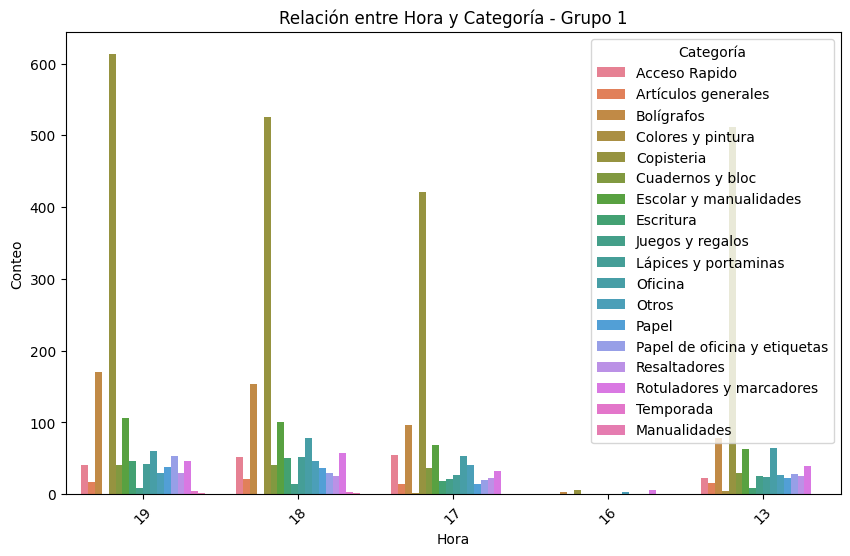

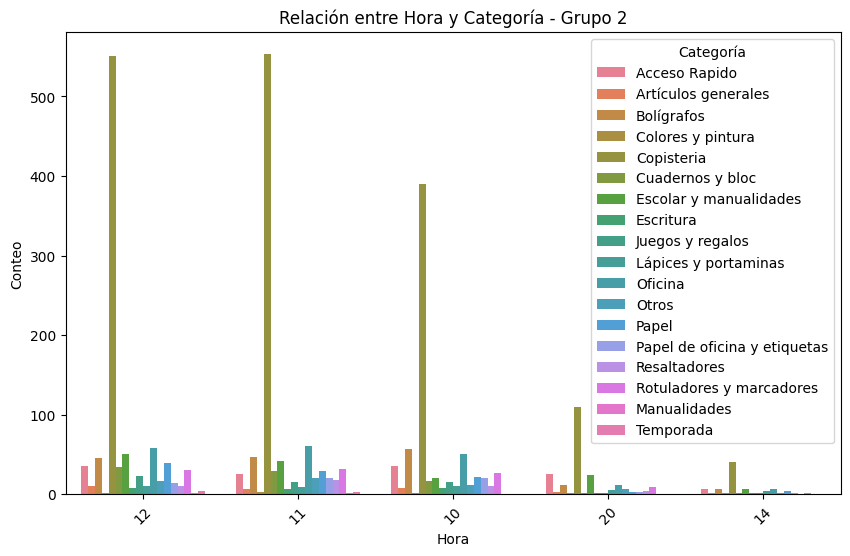

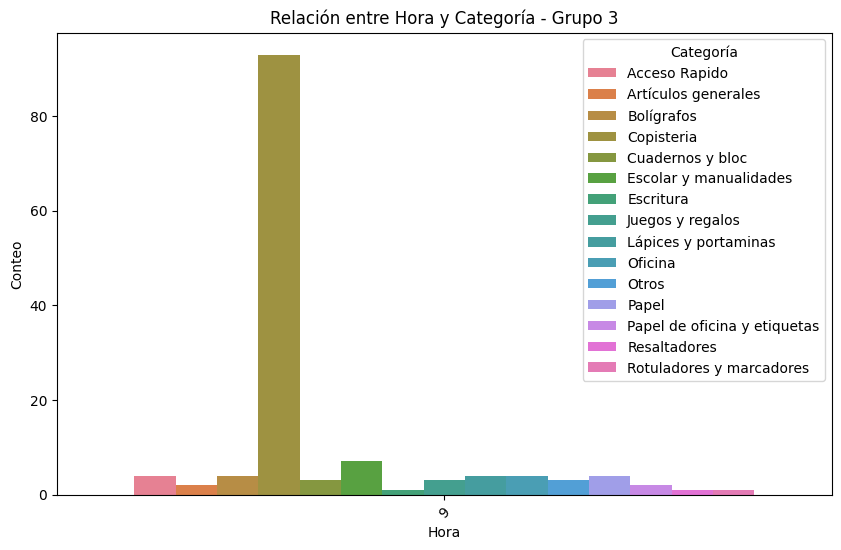

In [14]:
plot_categorical_relationship_fin(ventas, "Hora","Categoría")

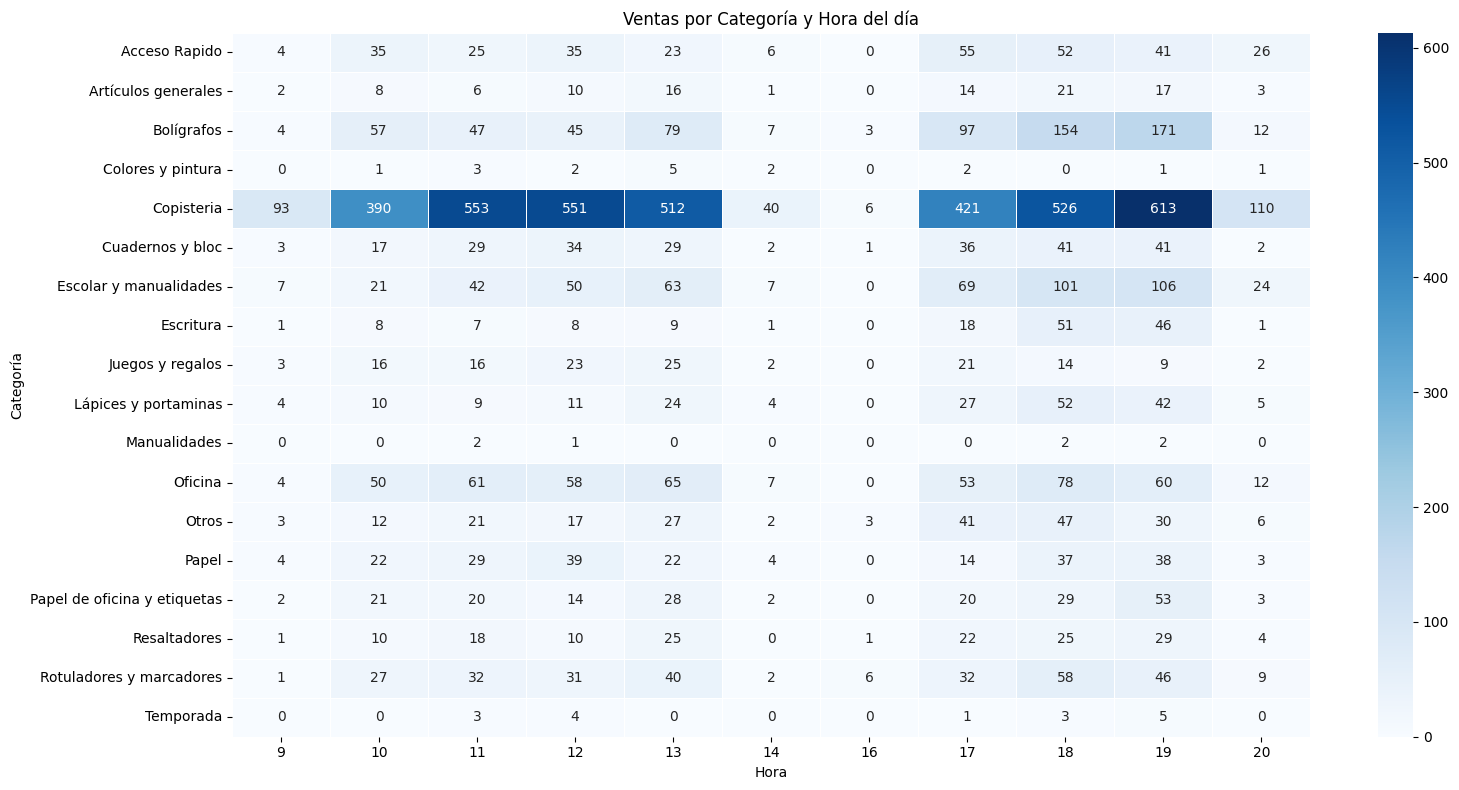

In [15]:
pivot = pd.crosstab(ventas['Categoría'], ventas['Hora'])

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title('Ventas por Categoría y Hora del día')
plt.xlabel('Hora')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import chi2_contingency

chi2, p_valor, gl, esperados = chi2_contingency(pivot)
print(f'P-valor: {p_valor:2f}')

if p_valor < 0.05:
    print('✅ Sí hay relación significativa entre categoría y hora')
else:
    print('❌ No hay relación significativa')

P-valor: 0.000000
✅ Sí hay relación significativa entre categoría y hora


In [17]:
n = pivot.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(pivot.shape) - 1)))
print(f'Cramér\'s V: {cramers_v:.3f}')

Cramér's V: 0.087


In [18]:
ventas.groupby('Categoría')['Hora'].agg(lambda x: x.value_counts().idxmax()).reset_index().rename(columns={'Hora': 'Hora pico'})

,Categoría,Hora pico
0,Acceso Rapido,17
1,Artículos generales,18
2,Bolígrafos,19
3,Colores y pintura,13
4,Copisteria,19
5,Cuadernos y bloc,19
6,Escolar y manualidades,19
7,Escritura,18
8,Juegos y regalos,13
9,Lápices y portaminas,18


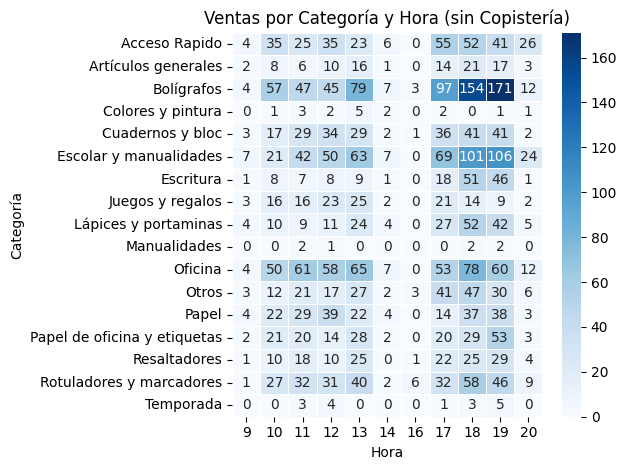

In [19]:
pivot_sin_copia = pivot[~pivot.index.str.contains('Copisteria|Copistería')]

sns.heatmap(pivot_sin_copia, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title('Ventas por Categoría y Hora (sin Copistería)')
plt.tight_layout()
plt.show()

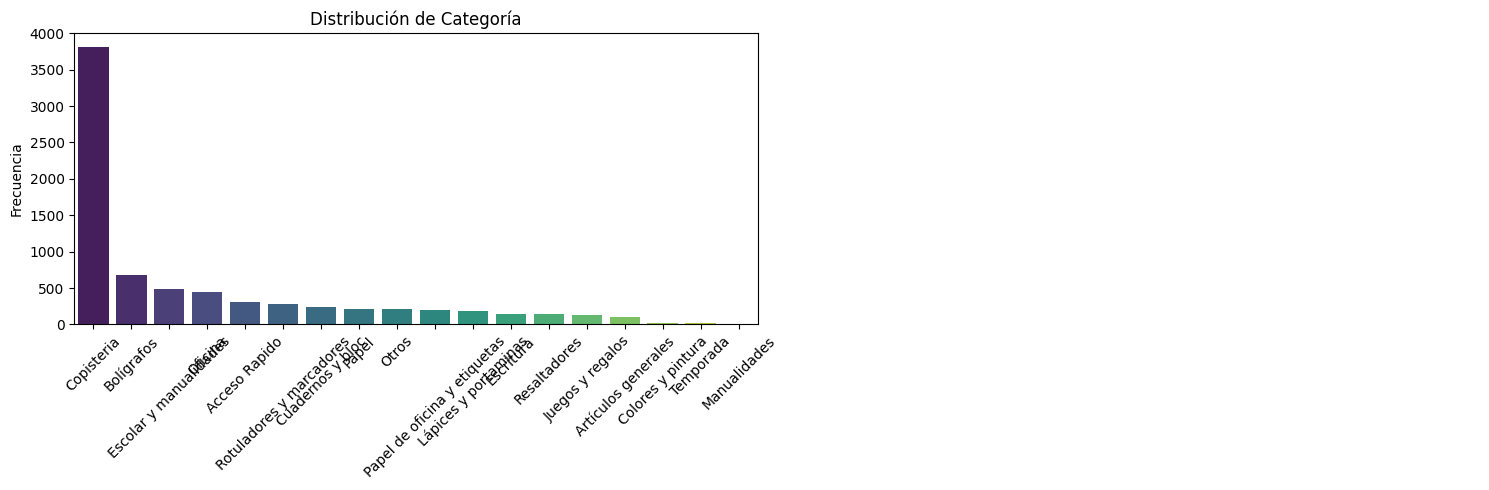

In [20]:
pinta_distribucion_categoricas(ventas, ['Categoría'])

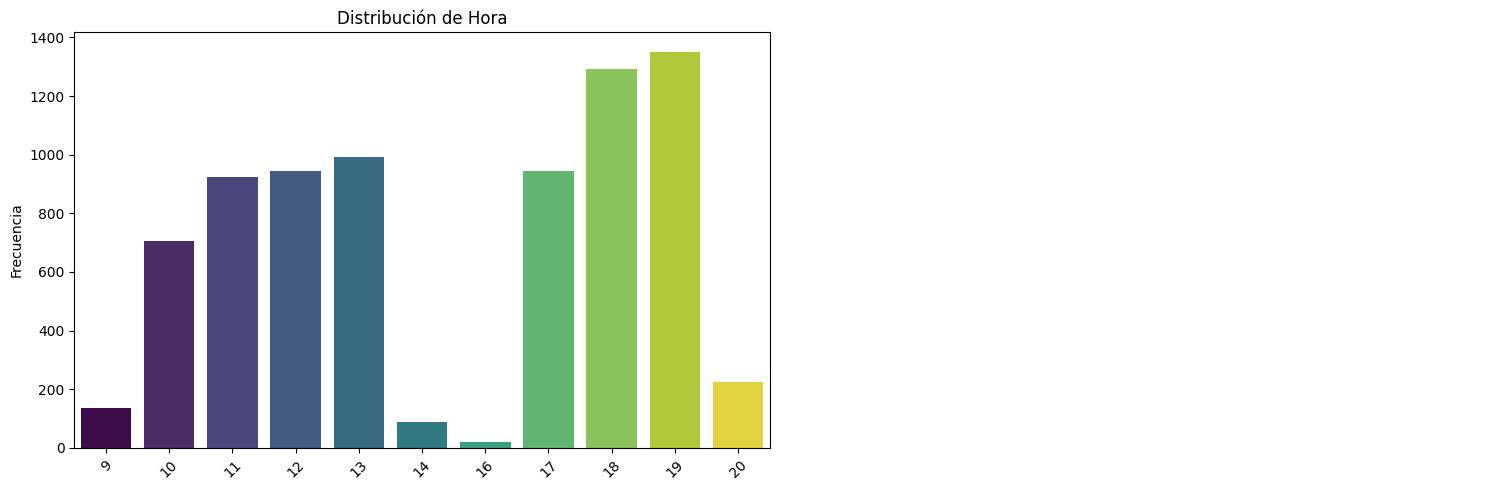

In [21]:
pinta_distribucion_categoricas(ventas, ["Hora"])

## Conclusiones: Categoría × Hora

### Estadísticas
- La relación entre categoría y hora existe pero es muy débil (Cramér's V = 0.087). La hora del día no determina qué categoría se compra.

### Comportamiento general
- Todas las categorías siguen el mismo patrón bimodal: mañana (10-13h) y tarde (17-19h). El negocio tiene dos picos claros independientemente de lo que se compre.

### Por categoría
- **Bolígrafos y Escolar** se compran más por la tarde, posiblemente estudiantes que vienen después del colegio.
- **Oficina** es más de mañana, posiblemente trabajadores que pasan antes o durante su jornada.
- **Manualidades** tiene volumen tan bajo que no hay patrón claro.

### Implicaciones para el negocio
- No tiene sentido hacer promociones por categoría según la hora porque el comportamiento es demasiado uniforme.
- Sí tendría sentido reforzar el personal en los picos de 12h y 19h, que son las horas más activas para casi todas las categorías.
- El hueco de 14-16h es una oportunidad: si hay demanda perdida en ese horario, abrir podría incrementar ventas especialmente en Oficina.

In [22]:
# Nulos
print(glovo.isnull().sum())
print('---')
# Tipos de datos
print(glovo.dtypes)
print('---')
# Duplicados
print(f'Duplicados: {glovo.duplicated().sum()}')
print('---')
# Estadísticas básicas
glovo.describe()

Name             0
Description      1
Category         0
Price            0
Qty              0
SalesIncVAT      0
Discount         0
NetIncVAT        0
NetExcVAT        0
TotalCost        0
Margin           0
MarginPercent    0
dtype: int64
---
Name                 str
Description          str
Category             str
Price            float64
Qty                int64
SalesIncVAT      float64
Discount         float64
NetIncVAT        float64
NetExcVAT        float64
TotalCost        float64
Margin           float64
MarginPercent    float64
dtype: object
---
Duplicados: 0
---


,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,4.303559,2.372881,11.431356,-0.715254,12.146610,10.200000,5.048983,5.151017,0.523744
std,3.208444,2.041790,13.515844,2.247340,12.990504,10.676336,5.774381,5.660859,0.202825
min,0.000000,1.000000,0.000000,-12.600000,1.000000,0.830000,0.000000,-1.500000,-0.222200
25%,2.645000,1.000000,3.095000,0.000000,3.550000,3.010000,1.340000,1.520000,0.460650
50%,3.450000,1.000000,5.850000,0.000000,5.990000,5.280000,2.490000,2.600000,0.519000
75%,5.990000,3.000000,16.165000,0.000000,16.165000,13.645000,6.565000,6.475000,0.632100
max,15.450000,9.000000,63.350000,1.450000,63.350000,52.360000,27.230000,25.130000,1.000000


In [23]:
print(glovo.columns.tolist())
print(glovo.shape)
glovo.head()

['Name', 'Description', 'Category', 'Price', 'Qty', 'SalesIncVAT', 'Discount', 'NetIncVAT', 'NetExcVAT', 'TotalCost', 'Margin', 'MarginPercent']
(59, 12)


,Name,Description,Category,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,5 Boligrafos Bic Cristal,BIC,0.00,3,0.00,-6.75,6.75,6.75,8.25,-1.50,-0.2222
1,5 Boligrafos Bic Cristal Medium,5 Boligrafos Bic Cristal Medium,BIC,2.25,1,2.25,0.00,2.25,1.86,0.00,1.86,1.0000
2,Afilador Faber-Castell deposito trans,Afilador Faber-Castell deposito trans,Afilador,2.00,2,4.00,0.00,4.00,3.31,0.94,2.37,0.7160
3,Bloc Cartulina Praxton,Bloc Cartulina Praxton,Blocs,4.00,9,36.00,0.00,36.00,29.79,5.22,24.57,0.8248
4,Bloc de Charol Praxton 10H,Bloc de Charol Praxton 10H,Blocs,2.30,6,13.80,0.00,13.80,11.40,2.10,9.30,0.8158


In [24]:
glovo.describe()

,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,4.303559,2.372881,11.431356,-0.715254,12.146610,10.200000,5.048983,5.151017,0.523744
std,3.208444,2.041790,13.515844,2.247340,12.990504,10.676336,5.774381,5.660859,0.202825
min,0.000000,1.000000,0.000000,-12.600000,1.000000,0.830000,0.000000,-1.500000,-0.222200
25%,2.645000,1.000000,3.095000,0.000000,3.550000,3.010000,1.340000,1.520000,0.460650
50%,3.450000,1.000000,5.850000,0.000000,5.990000,5.280000,2.490000,2.600000,0.519000
75%,5.990000,3.000000,16.165000,0.000000,16.165000,13.645000,6.565000,6.475000,0.632100
max,15.450000,9.000000,63.350000,1.450000,63.350000,52.360000,27.230000,25.130000,1.000000


In [25]:
glovo.isnull().sum()

Name             0
Description      1
Category         0
Price            0
Qty              0
SalesIncVAT      0
Discount         0
NetIncVAT        0
NetExcVAT        0
TotalCost        0
Margin           0
MarginPercent    0
dtype: int64

(5, 2)


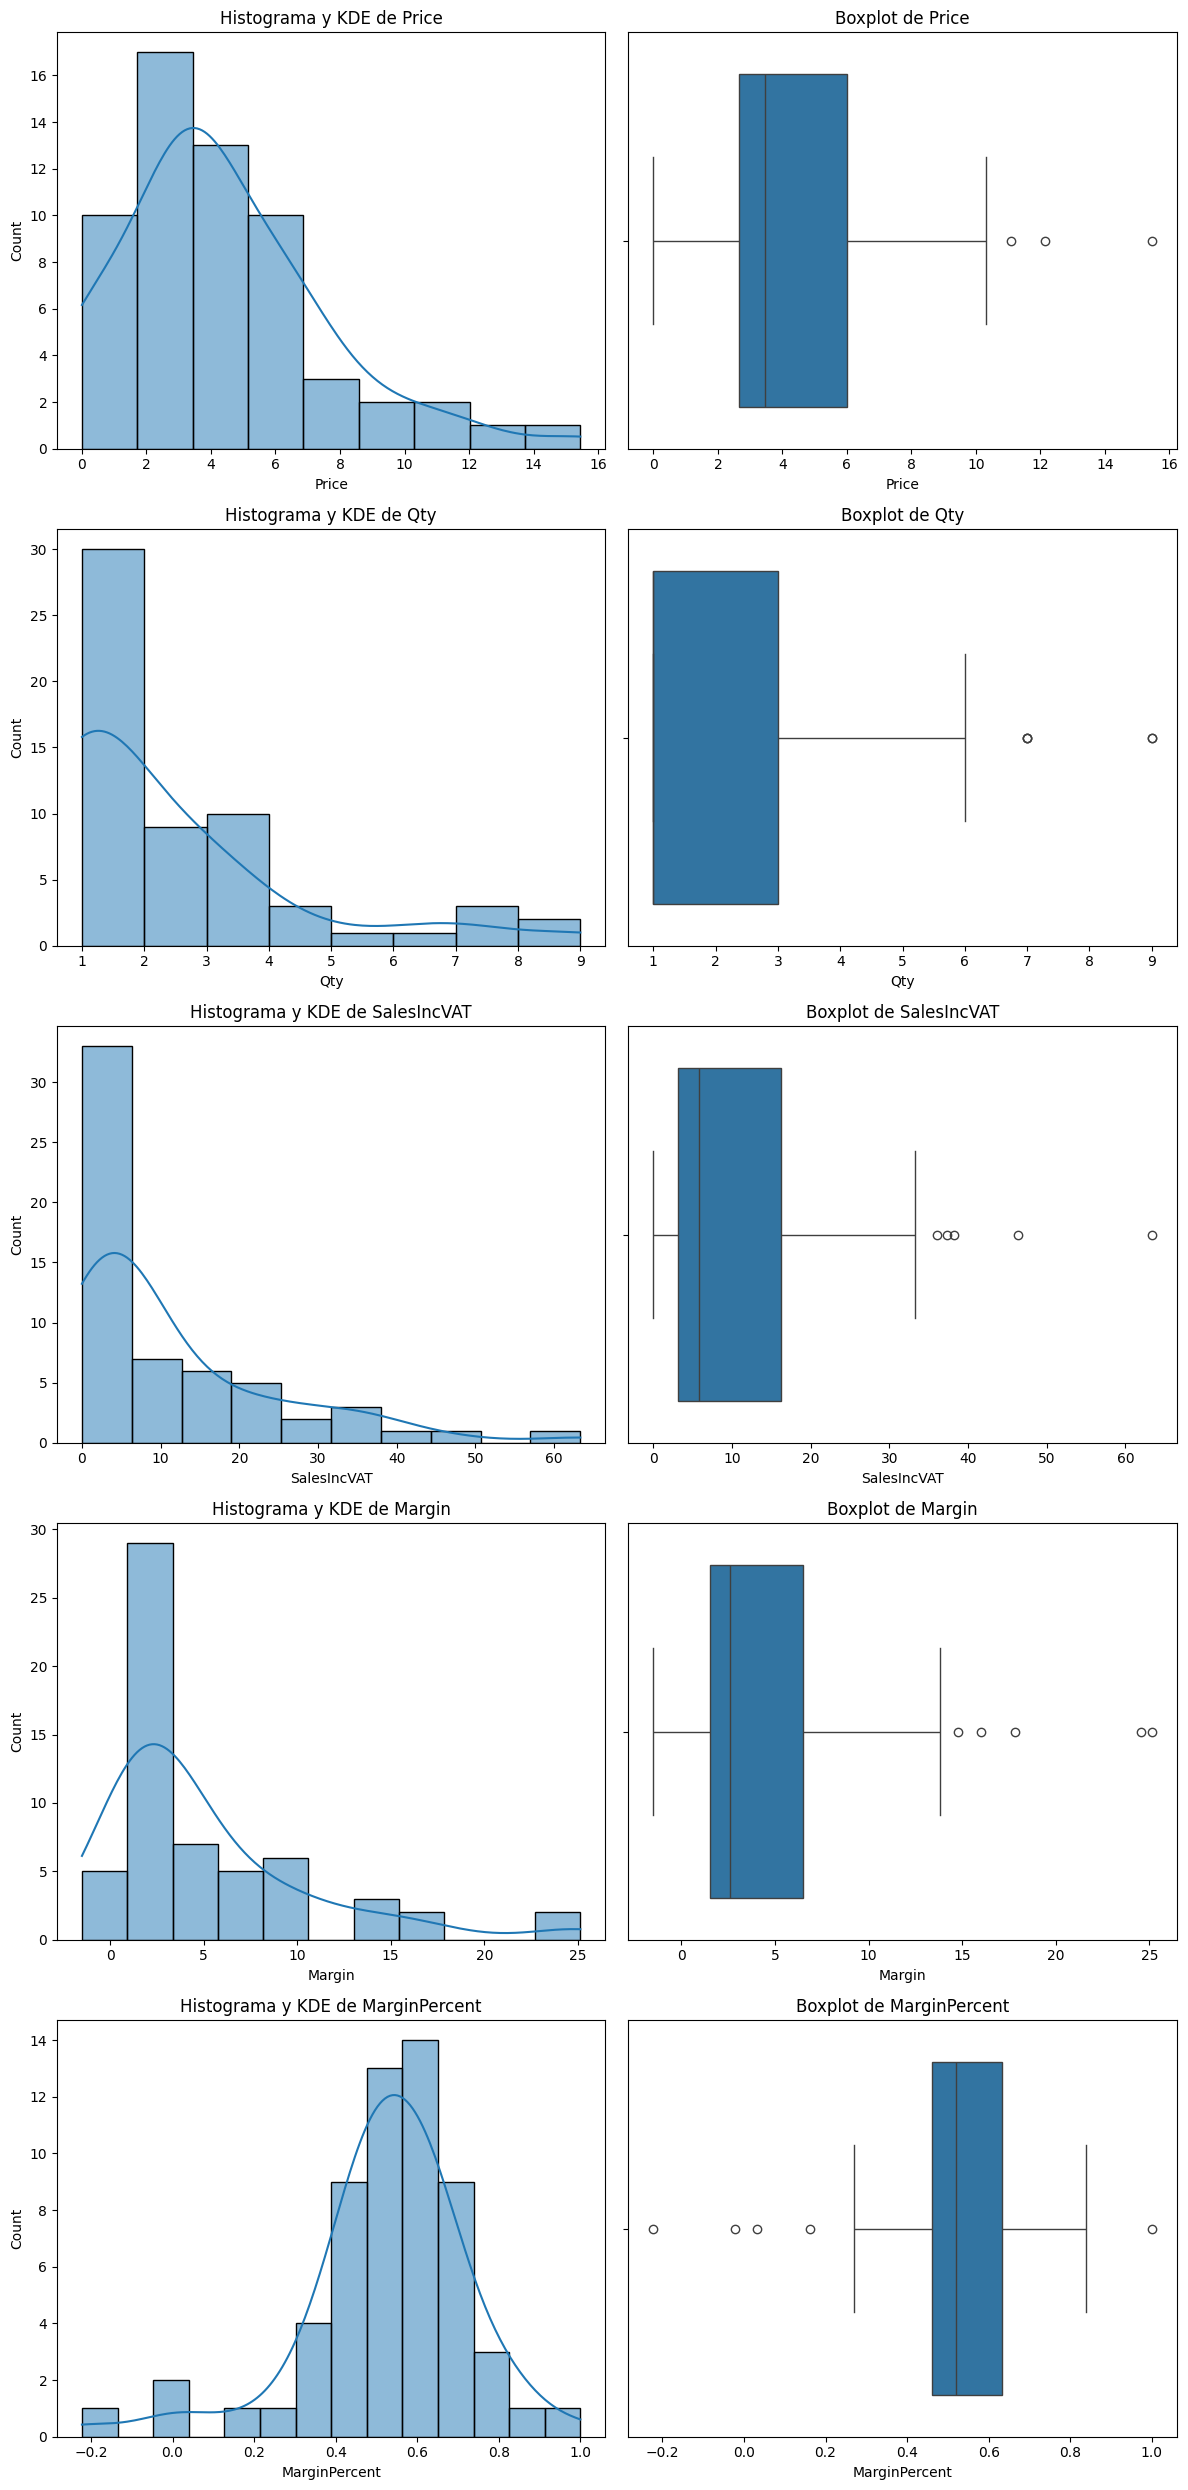

In [26]:
plot_combined_graphs(glovo, ['Price', 'Qty', 'SalesIncVAT', 'Margin', 'MarginPercent'])

## Análisis de variables numéricas — Glovo

### Price (Precio)
- Catálogo de bajo precio, la mayoría entre 1€ y 6€.
- Distribución sesgada a la derecha con 3 outliers por encima de 8€.

### Qty (Cantidad vendida)
- Volumen muy bajo, la mayoría de productos se venden entre 1 y 3 unidades.
- 2 outliers destacados con 7 y 9 unidades vendidas.

### SalesIncVAT (Ventas totales)
- La mayoría de productos generan menos de 10€ en ventas totales.
- Distribución muy sesgada, con outliers que llegan a 60€.

### Margin (Margen bruto €)
- Márgenes absolutos bajos, la mayoría entre 0€ y 5€ por producto.
- Outliers que llegan a 25€, probablemente los productos con más unidades vendidas.

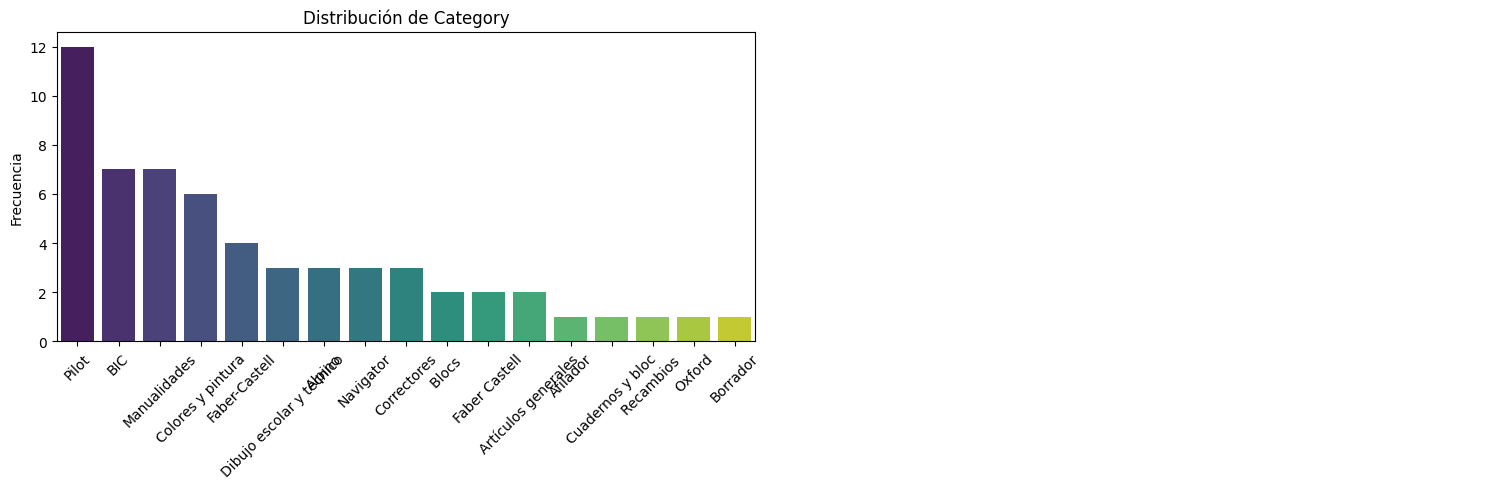

In [27]:
pinta_distribucion_categoricas(glovo, ['Category'])

## Análisis de categorías — Glovo

### Categorías más representadas
- **Pilot** es la categoría con más productos (12), seguida de **BIC** y **Manualidades** (7 cada una).
- **Colores y pintura** y **Faber-Castell** tienen 6 productos cada una.
- El resto de categorías tienen muy poca presencia, con 1-3 productos.

### Conclusiones
- El catálogo de Glovo está muy orientado a **material de escritura** (Pilot, BIC, Faber-Castell) y **manualidades**.
- Hay una ausencia notable de copistería, que es el motor del negocio en TPV. Tiene sentido porque copistería no se puede hacer a domicilio.
- Categorías como **Blocs, Cuadernos, Correctores** tienen muy poca presencia, podría ser una oportunidad para ampliar el catálogo.

In [28]:
glovo.sort_values('Qty', ascending=False).head(10)[['Name', 'Category', 'Qty', 'Margin', 'MarginPercent']]

,Name,Category,Qty,Margin,MarginPercent
3,Bloc Cartulina Praxton,Blocs,9,24.57,0.8248
50,Plastilina JOVI 90/15 10 Barra,Manualidades,9,16.02,0.5190
13,Borrable Frixion clicker 0.7 Negro,Pilot,7,9.79,0.4997
39,Navigator 80,Navigator,7,25.13,0.4800
51,Plastilina JOVI 90/15 6 Barra,Manualidades,7,10.57,0.5720
4,Bloc de Charol Praxton 10H,Blocs,6,9.30,0.8158
23,EVA Foam 10 colores,Manualidades,5,17.80,0.5855
32,Goma Milán 430,Borrador,4,2.11,0.7970
24,EVA Foam 4 colores purpurina,Manualidades,4,9.32,0.4551
38,Navigator 120 250H,Navigator,4,13.84,0.5440


## Productos más vendidos — Glovo

### Top 10 por unidades vendidas
- **Bloc Cartulina Praxton** y **Plastilina JOVI 90/15 10 Barra** son los más vendidos con 9 unidades cada uno, y además tienen buenos márgenes (82% y 52%).
- **Navigator 80** con 7 unidades es el más rentable en margen absoluto (25.13€) aunque con un margen del 48%.
- **Manualidades** aparece 4 veces en el top 10, es la categoría más vendida.
- **Blocs** tiene los mejores márgenes porcentuales (82% y 81%).

### Conclusiones
- Los productos más vendidos coinciden con los más rentables, lo cual es muy positivo.
- Manualidades y Blocs son las categorías estrella de Glovo.
- Navigator 80 destaca por generar el mayor margen absoluto.

In [29]:
glovo[glovo['Margin'] < 0][['Name', 'Category', 'Qty', 'Margin', 'MarginPercent']]

,Name,Category,Qty,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,BIC,3,-1.50,-0.2222
40,Pack 12 aquarela,Faber Castell,1,-0.07,-0.0232


## Productos con margen negativo — Glovo

Solo 2 productos de 59 tienen margen negativo, lo que indica que el catálogo de Glovo está bien calibrado en precios.

| Producto | Categoría | Unidades | Margen € | Margen % |
|---|---|---|---|---|
| 5 Bolígrafos Bic Cristal | BIC | 3 | -1.50€ | -22.2% |
| Pack 12 aquarela | Faber Castell | 1 | -0.07€ | -2.3% |

### Conclusiones
- El margen negativo de ambos productos se debe a un **error humano en el registro del precio unitario en el sistema**, no a una pérdida real.
- La ganancia fue real en ambos casos.
- Se recomienda corregir los precios en el sistema para que los datos reflejen la realidad.

In [30]:
glovo.groupby('Category').agg(
    Productos=('Name', 'count'),
    Qty_total=('Qty', 'sum'),
    Ventas=('SalesIncVAT', 'sum'),
    Margen=('Margin', 'sum'),
    Margen_pct_medio=('MarginPercent', 'mean')
).sort_values('Ventas', ascending=False)

,Productos,Qty_total,Ventas,Margen,Margen_pct_medio
Category,,,,,
Manualidades,7,31,186.10,74.91,0.490043
Navigator,3,14,127.45,52.02,0.499467
Colores y pintura,6,13,102.30,35.54,0.451033
Pilot,12,22,70.97,31.82,0.550325
Blocs,2,15,49.80,33.87,0.820300
BIC,7,10,35.34,10.43,0.396729
Alpino,3,5,29.20,14.34,0.605367
Cuadernos y bloc,1,3,17.97,2.40,0.161600
Faber-Castell,4,7,13.55,11.39,0.523400


## Análisis por categoría — Glovo

### Ranking por ventas totales

| Categoría | Productos | Uds vendidas | Ventas € | Margen € | Margen % medio |
|---|---|---|---|---|---|
| Manualidades | 7 | 31 | 186.10€ | 74.91€ | 49% |
| Navigator | 3 | 14 | 127.45€ | 52.02€ | 50% |
| Colores y pintura | 6 | 13 | 102.30€ | 35.54€ | 45% |
| Pilot | 12 | 22 | 70.97€ | 31.82€ | 55% |
| Blocs | 2 | 15 | 49.80€ | 33.87€ | 82% |

### Conclusiones
- **Manualidades** es la categoría líder en ventas (186€) y unidades vendidas (31).
- **Blocs** es la categoría más rentable porcentualmente con un 82% de margen, a pesar de tener solo 2 productos.
- **Navigator** genera mucho margen absoluto (52€) con solo 3 productos, muy eficiente.
- **Pilot** tiene 12 productos pero genera menos ventas que Navigator con 3, su catálogo está sobredimensionado.
- **Correctores** tiene 0€ de ventas registradas, posible error en el sistema.

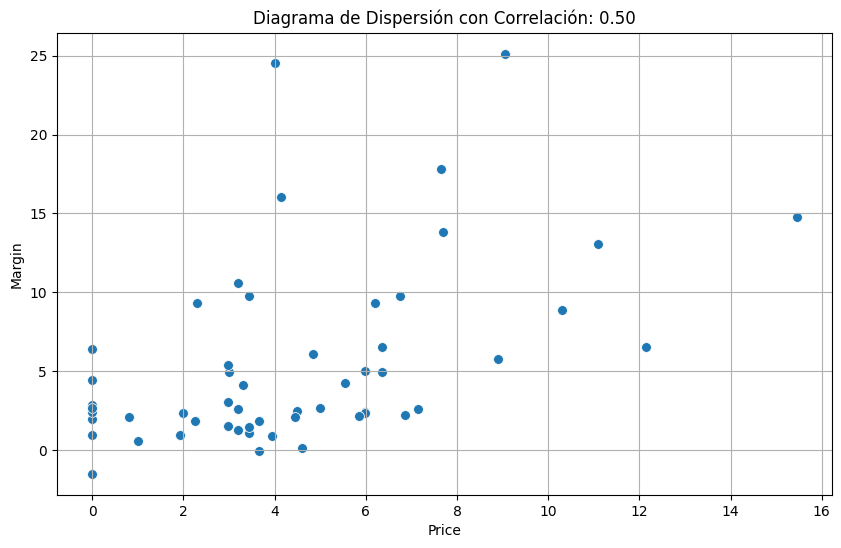

In [31]:
grafico_dispersion_con_correlacion(glovo, 'Price', 'Margin', mostrar_correlacion=True)

## Relación Precio vs Margen — Glovo

### Correlación: 0.50 (moderada positiva)

A mayor precio del producto, mayor margen absoluto generado.

### Conclusiones
- La correlación de 0.50 indica una relación moderada, no perfecta. El precio no es el único factor que determina el margen.
- Los productos de precio bajo (0-2€) generan márgenes muy bajos o incluso negativos.
- Los outliers más rentables (margen > 15€) corresponden a productos de precio medio-alto (4-9€) con alto volumen de ventas, como Navigator 80 y Bloc Cartulina Praxton.
- Hay bastante dispersión en productos de precio 3-5€, lo que indica que en esa franja el margen depende más del coste que del precio de venta.

### Recomendación
Priorizar en el catálogo de Glovo productos de precio medio-alto (4-10€) ya que tienen mejor relación precio-margen.

In [32]:
ventas['Comida para consumir en el Lugar o para Llevar'].value_counts()

Comida para consumir en el Lugar o para Llevar
Eat in      7486
Take Out     129
Name: count, dtype: int64

In [33]:
productos_glovo = set(glovo['Name'].str.strip().str.lower())
productos_tpv = set(ventas['Producto'].str.strip().str.lower())

solo_glovo = productos_glovo - productos_tpv
solo_tpv = productos_tpv - productos_glovo
ambos = productos_glovo & productos_tpv

print(f'Solo en Glovo: {len(solo_glovo)}')
print(f'Solo en TPV: {len(solo_tpv)}')
print(f'En ambos canales: {len(ambos)}')

Solo en Glovo: 0
Solo en TPV: 798
En ambos canales: 58


In [34]:
# Ventas en tienda física (Eat in)
eat_in = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in'].groupby('Producto')['Cantidad'].sum()

# Ventas en Glovo (Take Out)
take_out = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out'].groupby('Producto')['Cantidad'].sum()

# Unir en un solo df
comparativa = pd.DataFrame({'Tienda': eat_in, 'Glovo': take_out}).fillna(0)

# Solo productos que están en ambos canales
comparativa = comparativa[(comparativa['Tienda'] > 0) & (comparativa['Glovo'] > 0)]

# Calcular porcentaje de cada canal
comparativa['Total'] = comparativa['Tienda'] + comparativa['Glovo']
comparativa['%_Tienda'] = (comparativa['Tienda'] / comparativa['Total'] * 100).round(1)
comparativa['%_Glovo'] = (comparativa['Glovo'] / comparativa['Total'] * 100).round(1)

comparativa.sort_values('%_Glovo', ascending=False)

,Tienda,Glovo,Total,%_Tienda,%_Glovo
Producto,,,,,
Plastilina JOVI 90/15 10 Barra,1.0,9.0,10.0,10.0,90.0
EVA Foam 4 colores purpurina,1.0,4.0,5.0,20.0,80.0
Navigator 120 250H,1.0,4.0,5.0,20.0,80.0
Fluorescente FABER-CASTELL Textliner 48 3+1,1.0,3.0,4.0,25.0,75.0
Bloc de Charol Praxton 10H,2.0,6.0,8.0,25.0,75.0
Cera BIC Plastidecor 12 c,2.0,5.0,7.0,28.6,71.4
Cera BIC Plastidecor 36 c,1.0,2.0,3.0,33.3,66.7
Finger Paint 6 c JOVI- Pintura de dedos 125ml,2.0,3.0,5.0,40.0,60.0
EVA Foam 10 colores,5.0,5.0,10.0,50.0,50.0


## Comparativa de ventas por canal — Tienda vs Glovo

### Productos con mayor peso en Glovo
- **Plastilina JOVI 90/15 10 Barra** — 90% Glovo vs 10% Tienda. Es un producto casi exclusivo de Glovo.
- **EVA Foam 4 colores purpurina** y **Navigator 120 250H** — 80% Glovo.
- **Fluorescente FABER-CASTELL** y **Bloc de Charol Praxton 10H** — 75% Glovo.

### Productos equilibrados entre canales (50/50)
- EVA Foam 10 colores, Finger Paint, Bloc Canson, G2 0.7 Verde, entre otros.
- Estos productos tienen demanda similar en ambos canales.

### Productos con mayor peso en Tienda física
- **Pegamento Barra Pritt 20g** — 97.6% Tienda.
- **Tippex Pocket Mouse** — 97.5% Tienda.
- **TippEx Micro tape Twist** — 97.1% Tienda.
- **Navigator 80** — 90.3% Tienda, a pesar de ser el más vendido en volumen total (72 uds).

### Conclusiones
- Los productos de **manualidades y colores** (Plastilina, EVA Foam, Ceras) tienen mucho más peso en Glovo, posiblemente porque se piden para proyectos en casa.
- Los productos de **oficina y escritura** (Pegamento, Tippex, Navigator 80) se compran principalmente en tienda, son compras de urgencia o rutina.
- **Navigator 80** es el más vendido en total pero casi exclusivamente en tienda (90%). Podría potenciarse en Glovo.
- Los productos 50/50 son candidatos a promocionar más en Glovo ya que ya tienen demanda en ambos canales.

In [35]:
eat_in = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in'].groupby('Producto')['Cantidad'].sum()
take_out = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out'].groupby('Producto')['Cantidad'].sum()

comparativa = pd.DataFrame({'Tienda': eat_in, 'Glovo': take_out}).fillna(0)
comparativa = comparativa[(comparativa['Tienda'] > 0) & (comparativa['Glovo'] > 0)]
comparativa['Total'] = comparativa['Tienda'] + comparativa['Glovo']
comparativa['%_Tienda'] = (comparativa['Tienda'] / comparativa['Total'] * 100).round(1)
comparativa['%_Glovo'] = (comparativa['Glovo'] / comparativa['Total'] * 100).round(1)

comparativa_sorted = comparativa.sort_values('%_Glovo', ascending=True).reset_index()

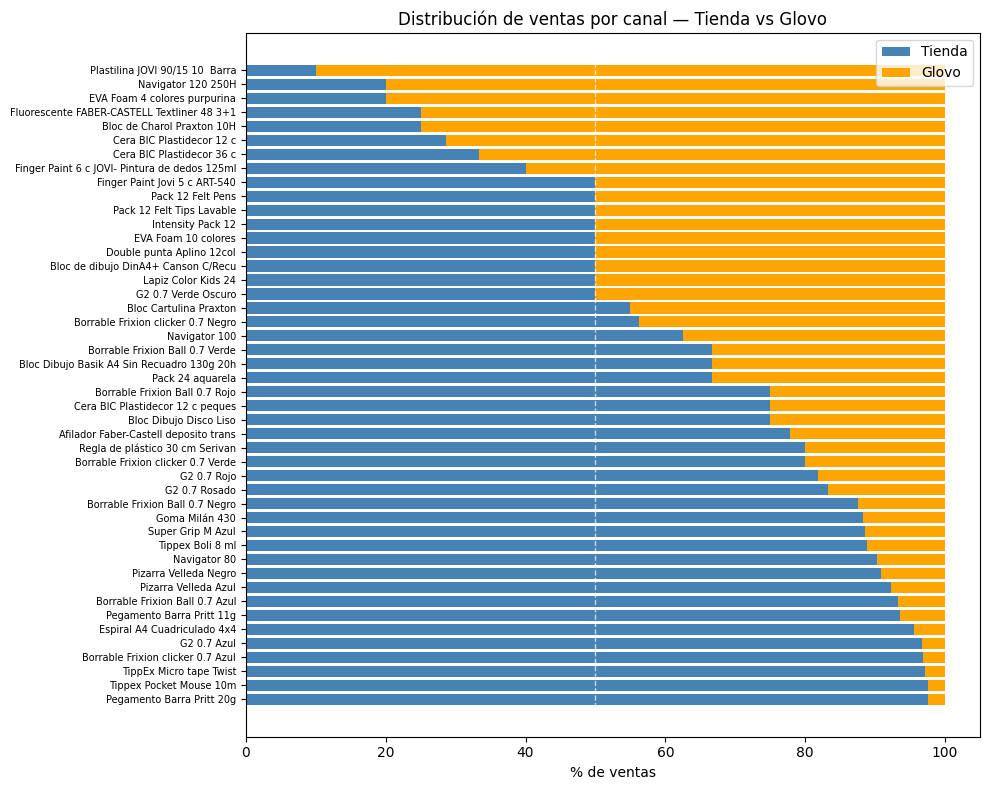

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

categorias = comparativa_sorted.index
pct_tienda = comparativa_sorted['%_Tienda']
pct_glovo = comparativa_sorted['%_Glovo']

bars1 = ax.barh(categorias, pct_tienda, color='steelblue', label='Tienda')
bars2 = ax.barh(categorias, pct_glovo, left=pct_tienda, color='orange', label='Glovo')

ax.axvline(50, color='white', lw=1, ls='--', alpha=0.7)
ax.set_xlabel('% de ventas')
ax.set_title('Distribución de ventas por canal — Tienda vs Glovo')
ax.legend()

ax.set_yticks(range(len(categorias)))
ax.set_yticklabels(comparativa_sorted['Producto'], fontsize=7)

plt.tight_layout()
plt.show()

In [37]:
margen_tienda = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Margen'].sum()
ventas_tienda = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Ventas NETAS'].sum()

margen_glovo = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Margen'].sum()
ventas_glovo_tpv = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Ventas NETAS'].sum()

print(f'Tienda — Ventas: {ventas_tienda:.2f}€ | Margen: {margen_tienda:.2f}€ | % Margen: {margen_tienda/ventas_tienda*100:.1f}%')
print(f'Glovo  — Ventas: {ventas_glovo_tpv:.2f}€ | Margen: {margen_glovo:.2f}€ | % Margen: {margen_glovo/ventas_glovo_tpv*100:.1f}%')

Tienda — Ventas: 14134.76€ | Margen: 7942.47€ | % Margen: 56.2%
Glovo  — Ventas: 601.80€ | Margen: 303.90€ | % Margen: 50.5%


In [38]:
ticket_tienda = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Ventas NETAS'].mean()
ticket_glovo = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Ventas NETAS'].mean()

print(f'Ticket medio Tienda: {ticket_tienda:.2f}€')
print(f'Ticket medio Glovo:  {ticket_glovo:.2f}€')

Ticket medio Tienda: 1.89€
Ticket medio Glovo:  4.67€


In [39]:
print(f'Transacciones Tienda: {len(ventas[ventas["Comida para consumir en el Lugar o para Llevar"] == "Eat in"])}')
print(f'Transacciones Glovo:  {len(ventas[ventas["Comida para consumir en el Lugar o para Llevar"] == "Take Out"])}')

Transacciones Tienda: 7486
Transacciones Glovo:  129


## ¿Es rentable Glovo? — Conclusiones

### Comparativa de métricas clave

| Métrica | Tienda | Glovo |
|---|---|---|
| Ventas totales | 14.134€ | 601€ |
| Margen total | 7.942€ | 303€ |
| % Margen | 56.2% | 50.5% |
| Ticket medio | 1.89€ | 4.67€ |
| Transacciones | 7.486 | 129 |

### Conclusiones

**Glovo SÍ es rentable pero es un canal secundario:**
- El margen % de Glovo (50.5%) es ligeramente inferior al de tienda (56.2%), pero sigue siendo muy bueno.
- El ticket medio de Glovo (4.67€) es **2.5 veces mayor** que el de tienda (1.89€), lo que indica que los pedidos de Glovo son de mayor valor.
- Sin embargo el volumen es muy bajo: solo 129 transacciones vs 7.486 de tienda, apenas el **1.7% del total**.

### Recomendación
Glovo es rentable y tiene un ticket medio alto, pero está muy infrautilizado. 
Potenciar el canal con más productos y visibilidad podría incrementar ingresos 
sin apenas coste adicional, ya que la infraestructura ya está montada.

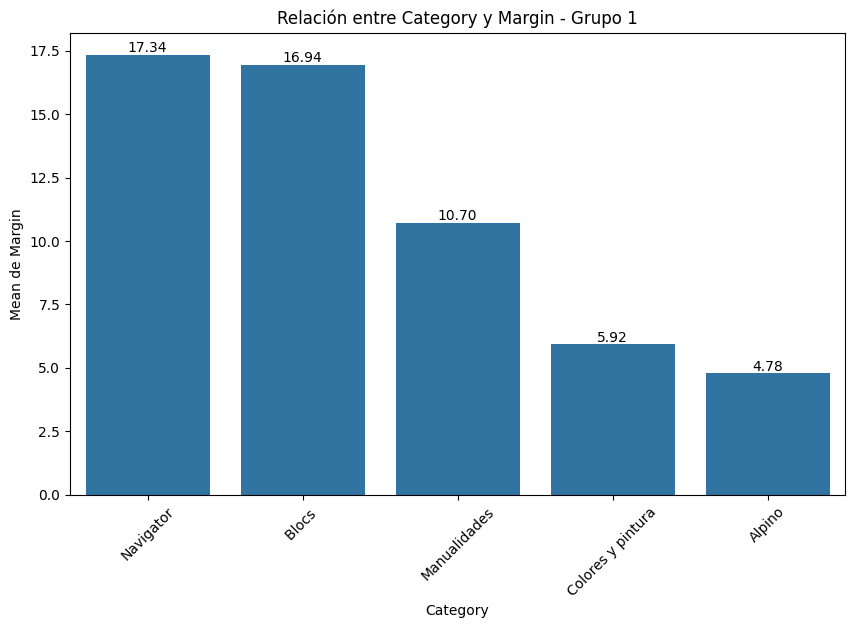

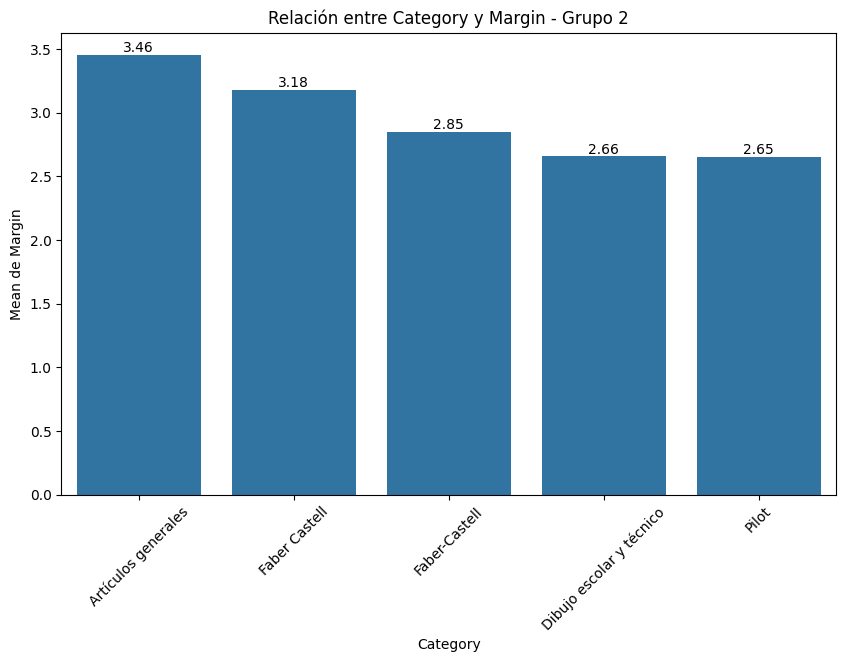

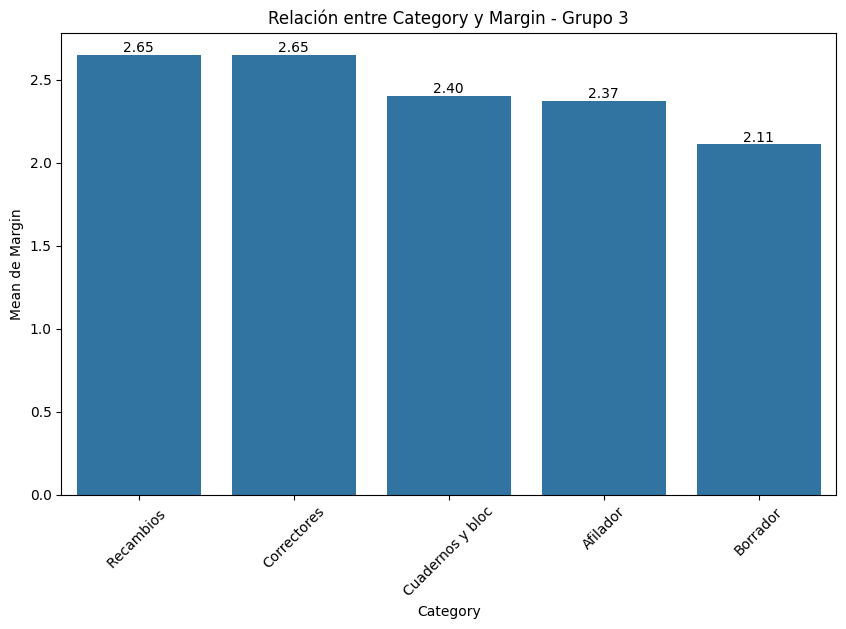

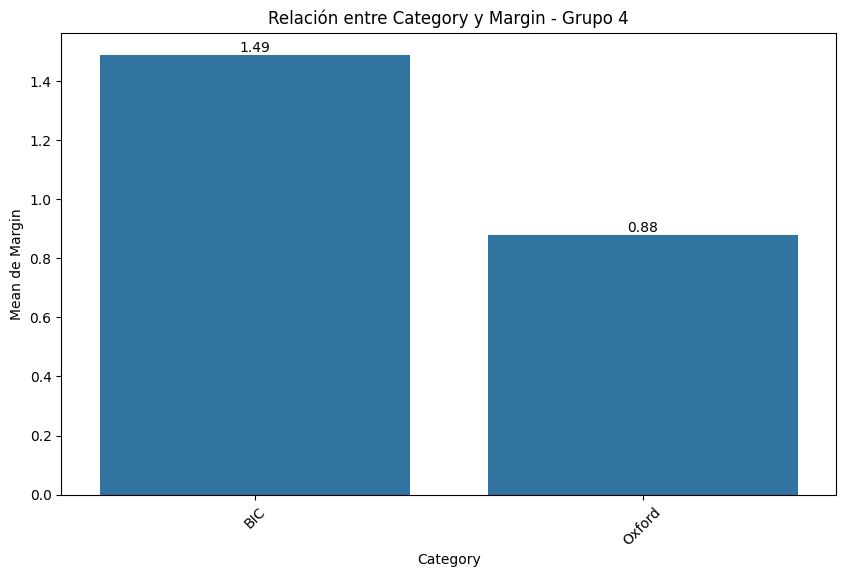

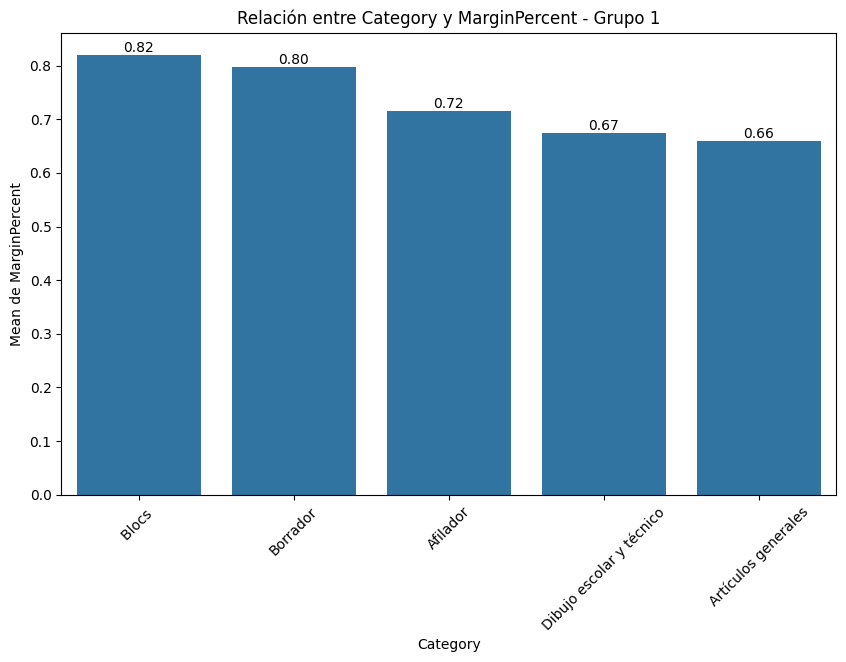

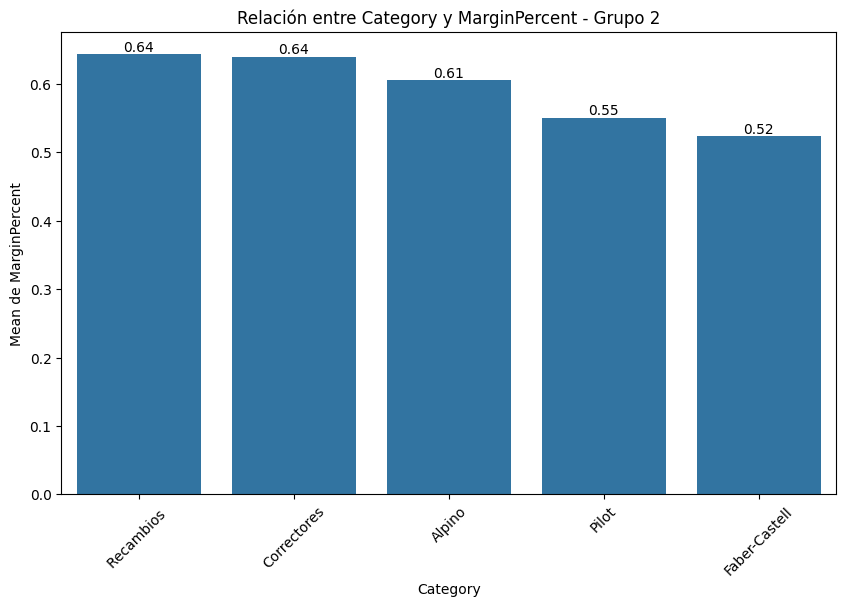

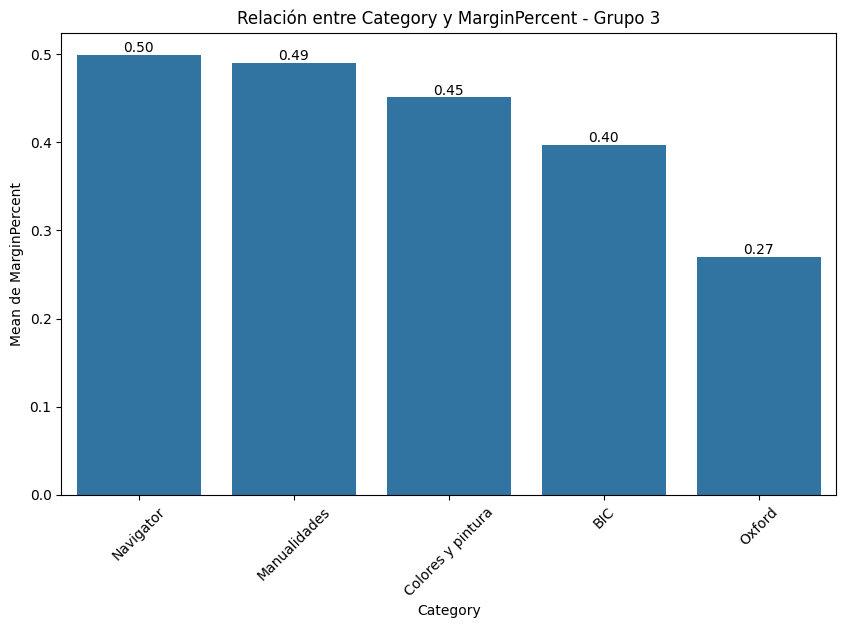

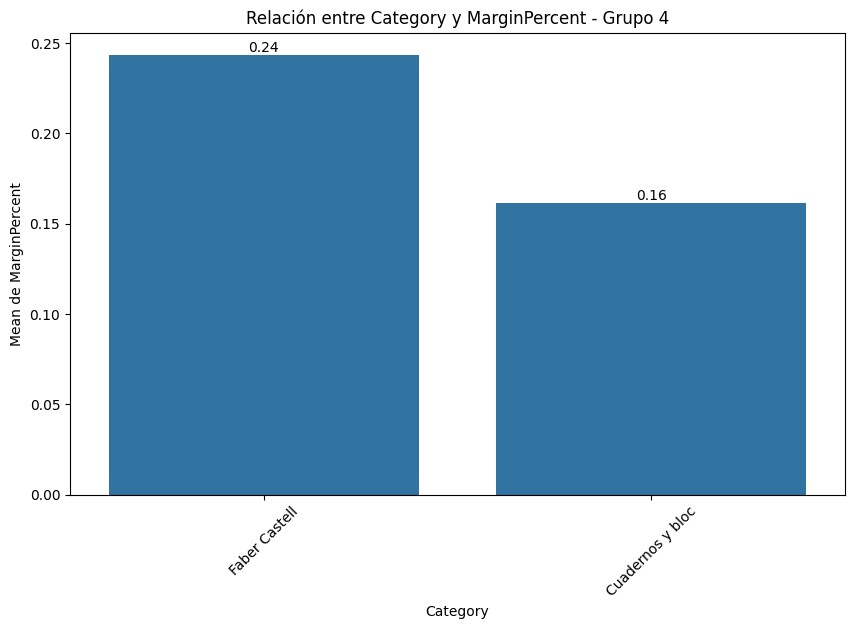

In [40]:
plot_categorical_numerical_relationship(glovo, 'Category', 'Margin', show_values=True)
plot_categorical_numerical_relationship(glovo, 'Category', 'MarginPercent', show_values=True)

In [41]:
from scipy.stats import mannwhitneyu

tienda_margen = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Margen']
glovo_margen = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Margen']

stat, p_valor = mannwhitneyu(tienda_margen, glovo_margen)
print(f'P-valor: {p_valor:.4f}')
if p_valor < 0.05:
    print('✅ Diferencia estadísticamente significativa entre los márgenes de ambos canales')
else:
    print('❌ No hay diferencia significativa')

P-valor: 0.0000
✅ Diferencia estadísticamente significativa entre los márgenes de ambos canales


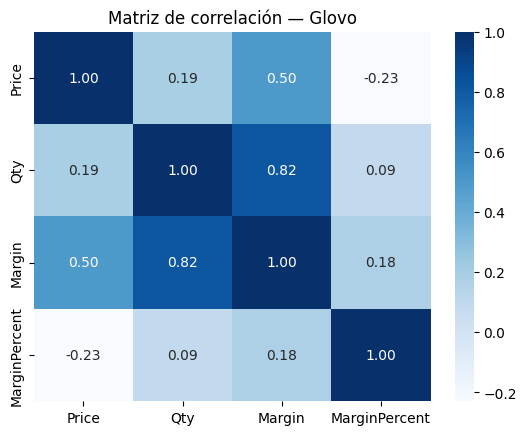

In [42]:
sns.heatmap(glovo[['Price', 'Qty', 'Margin', 'MarginPercent']].corr(), 
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Matriz de correlación — Glovo')
plt.show()